In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.pipeline.features.rpm_features import (
    RPM_FEATURES,
    TARGET,
    build_rpm_dataset,
    validate_rpm_dataset,
)

warnings.filterwarnings("ignore")


In [5]:
pd.set_option("display.max_columns", None)

# Pull silver.nba_player_gamelogs by season, engineer features, cache parquet.
from src.pipeline.gold import _read_silver_slice

CACHE_PATH = Path("data/cache/rpm_from_silver.parquet")
FORCE_REBUILD = False  # set True after changing rpm_features.py or silver data

# (season_year in silver, label used for holdout splits)
SEASONS = [
    ("2021-22", "S22"),
    ("2022-23", "S23"),
    ("2023-24", "S24"),
    ("2024-25", "S25"),
    ("2025-26", "S26"),
]
SEASON_TYPES = ("Regular Season", "Playoffs")


def load_season_from_silver(season_year: str) -> pd.DataFrame:
    parts = []
    for season_type in SEASON_TYPES:
        part = _read_silver_slice(season_year, season_type, league="nba")
        print(f"  {season_year} {season_type}: {len(part):,} rows")
        if not part.empty:
            parts.append(part)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True).sort_values("GAME_DATE")


df = None
if CACHE_PATH.exists() and not FORCE_REBUILD:
    cached = pd.read_parquet(CACHE_PATH)
    missing = [c for c in RPM_FEATURES if c not in cached.columns]
    if missing:
        print(
            f"  cache stale — missing {len(missing)} RPM_FEATURES "
            f"(e.g. {missing[:3]}); rebuilding…"
        )
    else:
        df = cached
        df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
        print(f"Loaded cache {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")

if df is None:
    season_dfs = []
    season_map = {}
    for i, (season_year, label) in enumerate(SEASONS):
        part = load_season_from_silver(season_year)
        if part.empty:
            print(f"  ⚠ skip {season_year}: no silver rows")
            continue
        season_map[len(season_dfs)] = label
        season_dfs.append(part)
        print(f"  → {label}: {len(part):,} raw rows")

    if not season_dfs:
        raise RuntimeError("No silver seasons loaded — run fetch_raw.py first")

    print("Building RPM features (this can take a few minutes)...")
    df = build_rpm_dataset(season_dfs, season_map=season_map)
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values("GAME_DATE").reset_index(drop=True)

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE_PATH, index=False)
    print(f"Wrote {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")

df.sample(5)


  cache stale — missing 9 RPM_FEATURES (e.g. ['REB_PER_MIN_season_avg', 'REB_PER_MIN_10_ewm', 'OREB_DREB_RATIO']); rebuilding…
  2021-22 Regular Season: 26,039 rows
  2021-22 Playoffs: 1,891 rows
  → S22: 27,930 raw rows
  2022-23 Regular Season: 25,894 rows
  2022-23 Playoffs: 1,728 rows
  → S23: 27,622 raw rows
  2023-24 Regular Season: 26,401 rows
  2023-24 Playoffs: 1,685 rows
  → S24: 28,086 raw rows
  2024-25 Regular Season: 26,306 rows
  2024-25 Playoffs: 1,804 rows
  → S25: 28,110 raw rows
  2025-26 Regular Season: 26,651 rows
  2025-26 Playoffs: 1,921 rows
  → S26: 28,572 raw rows
Building RPM features (this can take a few minutes)...
Wrote data\cache\rpm_from_silver.parquet: 118,434 rows × 234 cols


,GAME_ID,PLAYER_ID,BUILT_AT,SEASON_YEAR,SEASON_TYPE,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,SP_WORK_OFF_RATING,E_DEF_RATING,DEF_RATING,SP_WORK_DEF_RATING,E_NET_RATING,NET_RATING,SP_WORK_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,SP_WORK_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_CITY,TEAM_TRICODE,TEAM_SLUG,FIRST_NAME,FAMILY_NAME,NAME_I,PLAYER_SLUG,START_POSITION,COMMENT,JERSEY_NUM,MINUTES,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,ASSISTS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,FIELD_GOAL_PERCENTAGE,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_TEAM_ABBREVIATION,OPP_TEAM_NAME,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,POS,AGE,IS_PLAYOFF,TEAM_SPREAD,GAME_TOTAL,STARTING,REB_PER_MIN,RBC_PER_MIN,POSITION_ENC,player_REB_PER_MIN_roll5_mean,player_REB_PER_MIN_roll5_std,player_REB_PER_MIN_roll10_mean,player_REB_PER_MIN_roll10_std,player_REB_PER_MIN_ewma,player_REB_PER_MIN_expanding_mean,player_ORBC_roll5_mean,player_ORBC_roll5_std,player_ORBC_roll10_mean,player_ORBC_roll10_std,player_ORBC_ewma,player_ORBC_expanding_mean,player_DRBC_roll5_mean,player_DRBC_roll5_std,player_DRBC_roll10_mean,player_DRBC_roll10_std,player_DRBC_ewma,player_DRBC_expanding_mean,player_MIN_roll5_mean,player_MIN_roll5_std,player_MIN_roll10_mean,player_MIN_roll10_std,player_MIN_ewma,player_MIN_expanding_mean,player_MIN_season_mean,REB_PER_MIN_season_avg,RPM_SEASON_STD,REB_PER_MIN_10_ewm,REB_PER_MIN_P10_L10,REB_PER_MIN_P90_L10,REB_ROLL10_SLOPE,OREB_DREB_RATIO,RBC_PER_MIN_10_ewm,opp_team_TEAM_REB_PCT_roll10_mean,opp_team_TEAM_REB_PCT_roll10_std,opp_team_TEAM_REB_PCT_ewma,opp_team_TEAM_REB_PCT_expanding_mean,SEASON
111995,0022500924,1631108,2026-07-11 18:24:41.717644+00:00,2025-26,Regular Season,Max Christie,Max,1610612742,DAL,Dallas Mavericks,2026-03-08,DAL @ TOR,L,25.553333,1.0,11.0,0.091,0.0,7.0,0.00,0.0,0.0,0.000,1.0,2.0,3.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,2.0,-22.0,5.1,0.0,0.0,6.0,1,25:33,1.0,86.7,83.6,83.6,123.7,125.9,125.9,-37.1,-42.3,-42.3,0.056,0.5,7.1,0.032,0.074,0.052,14.3,14.3,0.091,0.091,0.197,0.213,101.47,102.37,85.31,102.37,-0.065,55.0,1.0,11.0,Dallas,DAL,mavericks,Max,Christie,M. Christie,max-christie,G,None,00,25:33,4.53,2.04,2.0,4.0,6.0,45.0,0.0,0.0,32.0,1.0,0.0,5.0,0.000,1.0,6.0,0.167,0.091,2.0,2.0,1.000,35.0,88.0,0.398,5.0,30.0,0.167,17.0,20.0,0.850,13.0,34.0,47.0,22.0,19.0,5.0,7.0,4.0,20.0,19.0,92.0,-30.0,89.5,92.0,116.5,120.8,-27.1,-28.8,0.629,1.16,15.8,0.315,0.712,0.509,0.190,0.426,0.475,103.7,100.5,83.75,100.0,0.340,1610612761,None,None,48.0,95.0,0.505,10.0,36.0,0.278,16.0,22.0,0.727,8.0,34.0,42.0,39.0,8.0,11.0,4.0,7.0,19.0,20.0,122.0,30.0,116.5,120.8,89.5,92.0,27.1,28.8,0.813,4.88,25.2,0.288,0.685,0.491,0.079,0.558,0.583,103.7,100.5,83.75,101.0,0.660,G,None,None,-10.0,233.5,1,0.117402,0.234803,2,0.139756,0.037801,0.130515,0.065945,0.128807,0.113837,1.8,

In [6]:
# Validate engineered frame (no GAME_ID×PLAYER_ID dups, RPM_FEATURES present)
summary = validate_rpm_dataset(df)
print(f"Validated RPM frame: {summary['rows']:,} rows × {summary['cols']} cols")
print(f"Features OK ({summary['features']}): all {len(RPM_FEATURES)} RPM_FEATURES present")
print("Season counts:")
print(pd.Series(summary["seasons"]).sort_index())

FEATURE_COLS = list(RPM_FEATURES)
print(df.shape)
df.sample(3)


Validated RPM frame: 118,434 rows × 234 cols
Features OK (14): all 14 RPM_FEATURES present
Season counts:
S22    23752
S23    23523
S24    23385
S25    23618
S26    24156
dtype: int64
(118434, 234)


,GAME_ID,PLAYER_ID,BUILT_AT,SEASON_YEAR,SEASON_TYPE,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,SP_WORK_OFF_RATING,E_DEF_RATING,DEF_RATING,SP_WORK_DEF_RATING,E_NET_RATING,NET_RATING,SP_WORK_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,SP_WORK_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_CITY,TEAM_TRICODE,TEAM_SLUG,FIRST_NAME,FAMILY_NAME,NAME_I,PLAYER_SLUG,START_POSITION,COMMENT,JERSEY_NUM,MINUTES,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,ASSISTS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,FIELD_GOAL_PERCENTAGE,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_TEAM_ABBREVIATION,OPP_TEAM_NAME,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,POS,AGE,IS_PLAYOFF,TEAM_SPREAD,GAME_TOTAL,STARTING,REB_PER_MIN,RBC_PER_MIN,POSITION_ENC,player_REB_PER_MIN_roll5_mean,player_REB_PER_MIN_roll5_std,player_REB_PER_MIN_roll10_mean,player_REB_PER_MIN_roll10_std,player_REB_PER_MIN_ewma,player_REB_PER_MIN_expanding_mean,player_ORBC_roll5_mean,player_ORBC_roll5_std,player_ORBC_roll10_mean,player_ORBC_roll10_std,player_ORBC_ewma,player_ORBC_expanding_mean,player_DRBC_roll5_mean,player_DRBC_roll5_std,player_DRBC_roll10_mean,player_DRBC_roll10_std,player_DRBC_ewma,player_DRBC_expanding_mean,player_MIN_roll5_mean,player_MIN_roll5_std,player_MIN_roll10_mean,player_MIN_roll10_std,player_MIN_ewma,player_MIN_expanding_mean,player_MIN_season_mean,REB_PER_MIN_season_avg,RPM_SEASON_STD,REB_PER_MIN_10_ewm,REB_PER_MIN_P10_L10,REB_PER_MIN_P90_L10,REB_ROLL10_SLOPE,OREB_DREB_RATIO,RBC_PER_MIN_10_ewm,opp_team_TEAM_REB_PCT_roll10_mean,opp_team_TEAM_REB_PCT_roll10_std,opp_team_TEAM_REB_PCT_ewma,opp_team_TEAM_REB_PCT_expanding_mean,SEASON
77524,0022401219,1642270,2026-07-12 19:20:21.680735+00:00,2024-25,Regular Season,Donovan Clingan,Donovan,1610612757,POR,Portland Trail Blazers,2024-12-15,POR @ PHX,L,19.350000,5.0,9.0,0.556,0.0,2.0,0.00,0.0,0.0,0.0,4.0,5.0,9.0,3.0,3.0,0.0,2.0,0.0,5.0,0.0,10.0,-2.0,28.3,0.0,0.0,26.0,1,19:21,1.0,92.0,95.0,95.0,92.6,93.0,93.0,-0.6,2.0,2.0,0.273,1.0,20.0,0.182,0.208,0.196,20.0,20.0,0.556,0.556,0.273,0.265,104.83,102.95,85.79,102.95,0.127,40.0,5.0,9.0,Portland,POR,blazers,Donovan,Clingan,D. Clingan,donovan-clingan,C,None,23,19:21,4.29,1.45,5.0,8.0,13.0,34.0,0.0,0.0,24.0,3.0,4.0,6.0,0.667,1.0,3.0,0.333,0.556,1.0,2.0,0.5,42.0,94.0,0.447,15.0,49.0,0.306,10.0,13.0,0.769,12.0,36.0,48.0,30.0,13.0,6.0,4.0,2.0,22.0,13.0,109.0,-7.0,108.2,111.2,120.4,118.4,-12.2,-7.1,0.714,2.31,21.0,0.302,0.740,0.515,0.133,0.527,0.547,98.5,98.0,81.67,98.0,0.467,1610612756,None,None,43.0,89.0,0.483,15.0,39.0,0.385,15.0,19.0,0.789,12.0,34.0,46.0,23.0,11.0,7.0,2.0,4.0,13.0,22.0,116.0,7.0,120.4,118.4,108.2,111.2,12.2,7.1,0.535,2.09,17.2,0.260,0.698,0.485,0.112,0.567,0.596,98.5,98.0,81.67,98.0,0.533,C,None,None,-11.0,230.0,1,0.465116,0.671835,0,0.492074,0.145446,0.380605,0.165642,0.442666,0.396718,8

In [7]:
# Feature list already validated via validate_rpm_dataset (RPM_FEATURES)
print(f"Features ({len(FEATURE_COLS)})")
print(FEATURE_COLS)
df[FEATURE_COLS].dtypes


Features (14)
['REB_PER_MIN_season_avg', 'REB_PER_MIN_10_ewm', 'OREB_DREB_RATIO', 'POSITION_ENC', 'RBC_PER_MIN_10_ewm', 'RPM_SEASON_STD', 'REB_ROLL10_SLOPE', 'REB_PER_MIN_P10_L10', 'REB_PER_MIN_P90_L10', 'player_ORBC_roll10_mean', 'player_DRBC_roll10_mean', 'player_MIN_roll5_mean', 'player_MIN_season_mean', 'opp_team_TEAM_REB_PCT_roll10_mean']


REB_PER_MIN_season_avg               float64
REB_PER_MIN_10_ewm                   float64
OREB_DREB_RATIO                      float64
POSITION_ENC                           int64
RBC_PER_MIN_10_ewm                   float64
RPM_SEASON_STD                       float64
REB_ROLL10_SLOPE                     float64
REB_PER_MIN_P10_L10                  float64
REB_PER_MIN_P90_L10                  float64
player_ORBC_roll10_mean              float64
player_DRBC_roll10_mean              float64
player_MIN_roll5_mean                float64
player_MIN_season_mean               float64
opp_team_TEAM_REB_PCT_roll10_mean    float64
dtype: object

In [8]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# CHANGED: S26 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = "S26"
ID_COLS = ["GAME_ID", "PLAYER_ID", "SEASON", "PLAYER_NAME", "GAME_DATE"]
TARGET_COL = TARGET  # "REB_PER_MIN"
ROLE_COL = "STARTING"

df_model = df[df["SEASON"] != HOLDOUT_SEASON].copy()   # S22–S25
df_holdout = df[df["SEASON"] == HOLDOUT_SEASON].copy()  # S26 blind test

KEEP_COLS = list(dict.fromkeys(
    FEATURE_COLS + ID_COLS + [TARGET_COL, ROLE_COL, "MIN"]
))

rpm_df = (
    df_model[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

rpm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = rpm_df[FEATURE_COLS].copy()
y = rpm_df[TARGET_COL]

print(f"Train pool (S22–S25) : {len(rpm_df):,} rows")
print(f"Holdout   (S26)      : {len(rpm_holdout):,} rows")
print(f"Date range (train)   : {rpm_df['GAME_DATE'].min().date()} → {rpm_df['GAME_DATE'].max().date()}")
print(f"Date range (holdout) : {rpm_holdout['GAME_DATE'].min().date()} → {rpm_holdout['GAME_DATE'].max().date()}")


Train pool (S22–S25) : 94,278 rows
Holdout   (S26)      : 24,156 rows
Date range (train)   : 2021-10-19 → 2025-06-22
Date range (holdout) : 2025-10-21 → 2026-06-13


In [9]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1344,
    max_depth             = 3,
    learning_rate         = 0.0199208375412252,
    subsample             = 0.6525095024077675,
    colsample_bytree      = 0.7424913081435832,
    reg_alpha             = 3.890568820995351,
    reg_lambda            = 4.755281357016035,
    min_child_weight      = 10,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds

In [10]:
# ── Helpers ───────────────────────────────────────────────────────────────────

RPM_TIERS = {
    "<0.15 reb/min":    lambda a: a < 0.15,
    "0.15-0.25 reb/min": lambda a: (a >= 0.15) & (a < 0.25),
    "0.25-0.40 reb/min": lambda a: (a >= 0.25) & (a < 0.40),
    "0.40+ reb/min":    lambda a: a >= 0.40,
}


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    CHANGED: now accepts `starting` (bool/int array) and reports
    stratified MAE + coverage across roles and RPM tiers.
    Pass `starting` from `rpm_df` / `rpm_holdout` aligned to the validation rows
    (`STARTING` may not be included in RPM_FEATURES).
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.4f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.4f} | Coverage: {r_cov:.1%}")

    # ── RPM-tier stratification ────────────────────────────────────────────────
    for tier, fn in RPM_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:20s} | n={mask.sum():5d} | MAE: {t_mae:.4f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = rpm_df.iloc[val_idx]["STARTING"].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]            for r in tscv_results]
r2s  = [r["r2"]             for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# CHANGED: splits are now on unique GAME_DATEs, not row indices.
# This ensures no single game date is split across train/val,
# which was the root cause of intra-game leakage in the original code.
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

assert rpm_df["GAME_DATE"].is_monotonic_increasing, "rpm_df must be sorted by GAME_DATE"

unique_dates = rpm_df["GAME_DATE"].unique()          # sorted unique game dates
n_dates      = len(unique_dates)

TRAIN_WINDOW = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE    = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS      = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # CHANGED: mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = rpm_df["GAME_DATE"].isin(train_dates)
    val_mask   = rpm_df["GAME_DATE"].isin(val_dates)

    X_tr,  X_val  = X[train_mask], X[val_mask]
    y_tr,  y_val  = y[train_mask], y[val_mask]
    starting_val  = rpm_df.loc[val_mask, "STARTING"].values

    label = (f"WF fold {fold+1}  "
             f"({train_dates[-1].date()} → {val_dates[-1].date()})")

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash masks so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last   = models
    preds_last    = preds
    X_val_last    = X_val
    y_val_last    = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]            for r in wf_results]
r2s  = [r["r2"]             for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# CHANGED: per-fold coverage table — catches folds where interval collapses
# or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# CHANGED: stratified MAE summary across all folds
print(f"\nPer-fold MAE by RPM tier:")
tier_keys = list(RPM_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>20}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>20.4f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.4f}  {bar}")

last_fold = wf_results[-1]

── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=15713 | MAE: 0.0714 | R²: 0.400 | 80% Coverage: 79.7%
  Starters   | n= 8717 | MAE: 0.0654 | Coverage: 80.8%
  Bench      | n= 6996 | MAE: 0.0790 | Coverage: 78.5%
  <0.15 reb/min        | n= 7296 | MAE: 0.0602 | Coverage: 77.1%
  0.15-0.25 reb/min    | n= 4663 | MAE: 0.0553 | Coverage: 92.7%
  0.25-0.40 reb/min    | n= 2847 | MAE: 0.0895 | Coverage: 76.6%
  0.40+ reb/min        | n=  907 | MAE: 0.1882 | Coverage: 44.4%

TSCV fold 2
  Overall  | n=15713 | MAE: 0.0703 | R²: 0.414 | 80% Coverage: 80.0%
  Starters   | n= 8825 | MAE: 0.0638 | Coverage: 81.5%
  Bench      | n= 6888 | MAE: 0.0785 | Coverage: 78.2%
  <0.15 reb/min        | n= 7352 | MAE: 0.0566 | Coverage: 79.4%
  0.15-0.25 reb/min    | n= 4592 | MAE: 0.0562 | Coverage: 91.4%
  0.25-0.40 reb/min    | n= 2838 | MAE: 0.0885 | Coverage: 75.1%
  0.40+ reb/min        | n=  931 | MAE: 0.1918 | Coverage: 44.1%

TSCV fold 3
  Overall  | 

In [11]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Residual Visuals

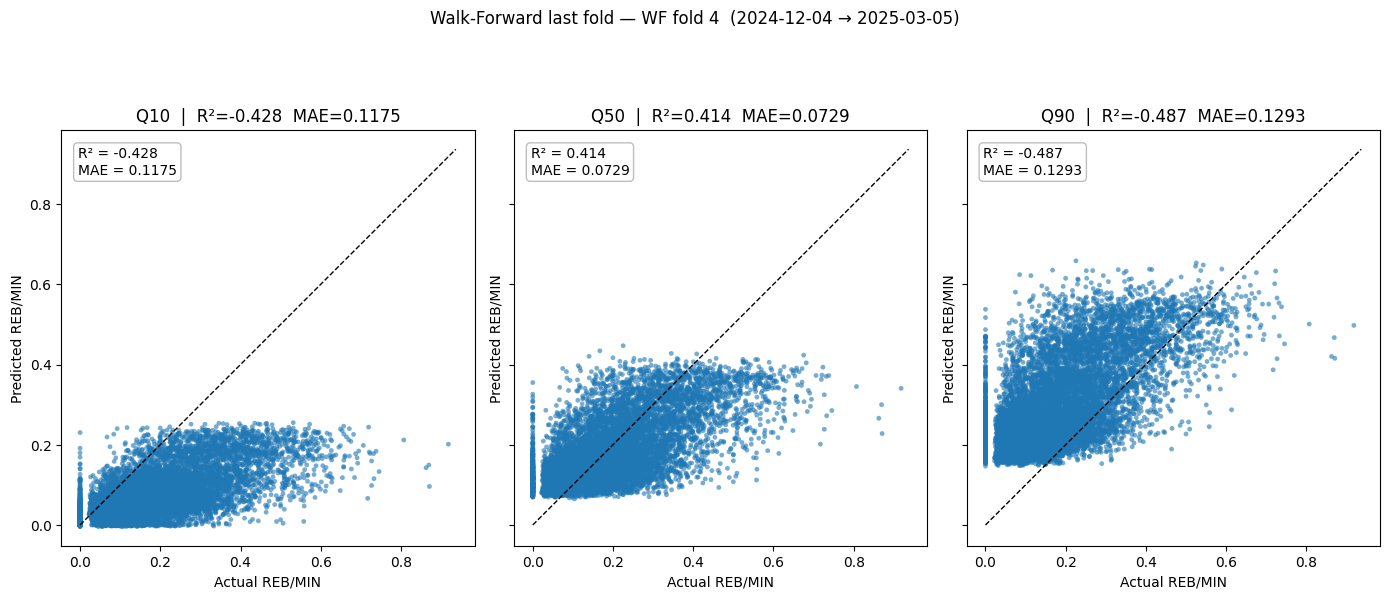

Per-quantile fit on last validation fold:
  Q10: R²=-0.428  MAE=0.1175
  Q50: R²=+0.414  MAE=0.0729
  Q90: R²=-0.487  MAE=0.1293

Coverage per quantile (should match quantile value):
  Q10: 10.3%  (target 10%, delta +0.3%)  ✓
  Q50: 49.4%  (target 50%, delta -0.6%)  ✓
  Q90: 89.3%  (target 90%, delta -0.7%)  ✓

80% interval width (Q10→Q90):
  mean   : 0.2278 reb/min
  median : 0.2134 reb/min
  std    : 0.0618 reb/min


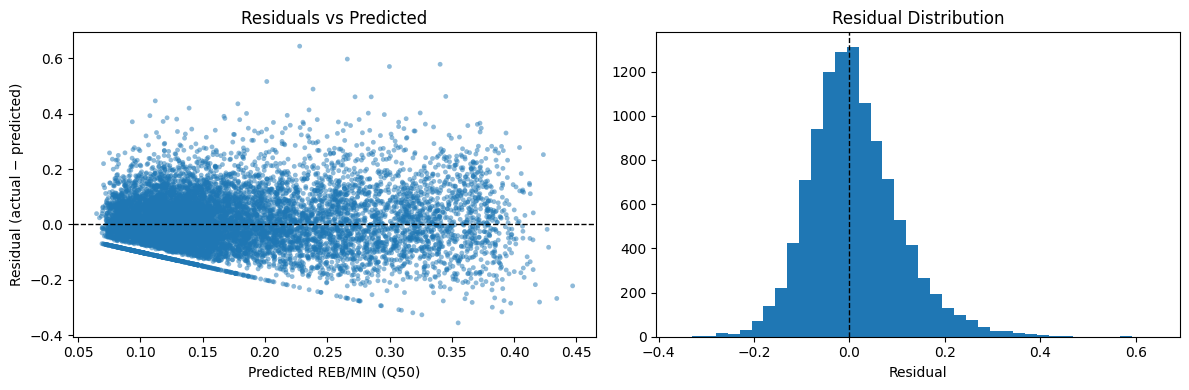


Residual summary:
  mean bias : +0.0105  (close to 0 = unbiased)
  std       : 0.0959

Residuals by role:
  Starters   | n= 6020 | bias=+0.0085 | std=0.0870
  Bench      | n= 4852 | bias=+0.0131 | std=0.1059

Residuals by RPM tier:
  <0.15 reb/min        | n= 4965 | bias=-0.0494 | std=0.0564
  0.15-0.25 reb/min    | n= 3160 | bias=+0.0201 | std=0.0668
  0.25-0.40 reb/min    | n= 1998 | bias=+0.0777 | std=0.0786
  0.40+ reb/min        | n=  749 | bias=+0.1881 | std=0.0967


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.4f}")
    ax.set_xlabel("Actual REB/MIN")
    ax.set_ylabel("Predicted REB/MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.4f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.4f}")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.4f} reb/min")
print(f"  median : {np.median(interval_width):.4f} reb/min")
print(f"  std    : {interval_width.std():.4f} reb/min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted REB/MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.4f}  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.4f}")

# ── residuals stratified by role and RPM tier ─────────────────────────────────
starting_last = rpm_df.loc[X_val_last.index, "STARTING"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")

print("\nResiduals by RPM tier:")
for tier, fn in RPM_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:20s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")


── q_0.10 ──


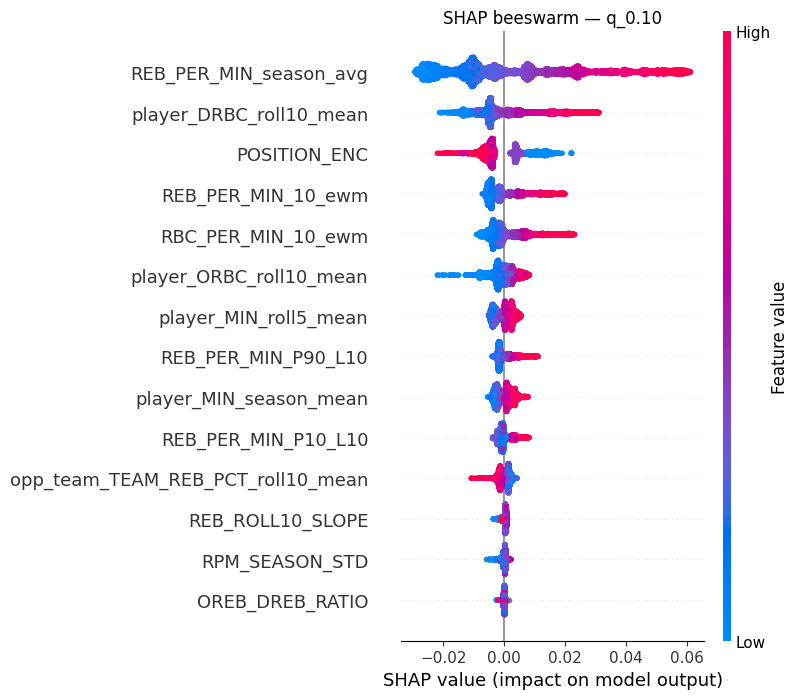


── q_0.50 ──


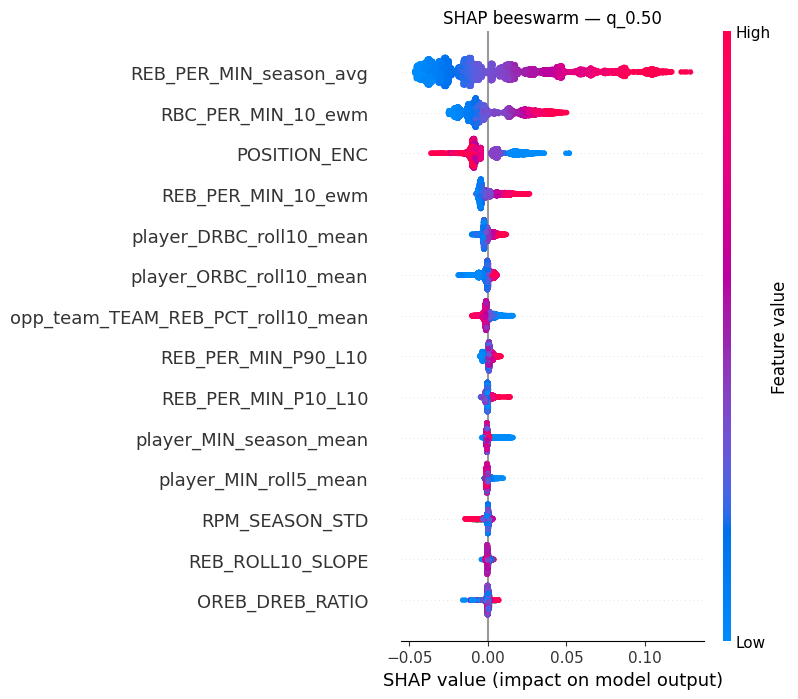


── q_0.90 ──


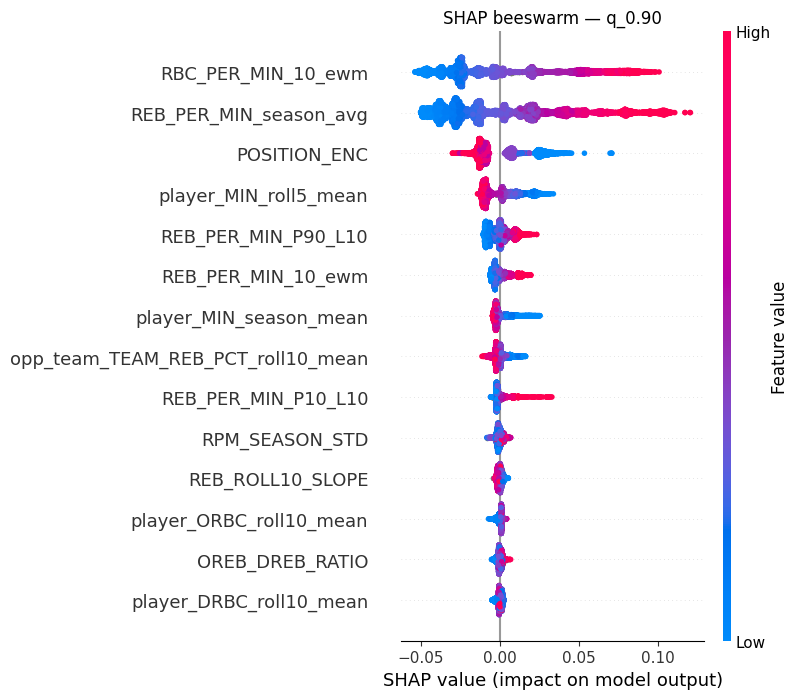

In [13]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

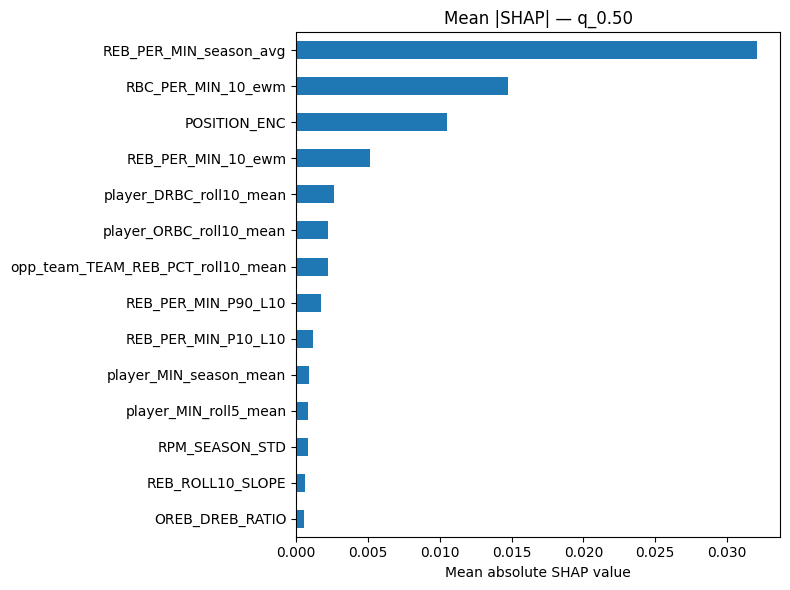

In [14]:
model = models_last["q_0.50"]

explainer   = shap.TreeExplainer(model, model_output="raw")
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [15]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(6)
pi_df["std"]        = pi_df["std"].round(6)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                              feature  importance       std  p_value  significant
1              REB_PER_MIN_season_avg    0.005622  0.000135      0.0         True
2                  RBC_PER_MIN_10_ewm    0.001188  0.000052      0.0         True
3                        POSITION_ENC    0.000943  0.000046      0.0         True
4                  REB_PER_MIN_10_ewm    0.000251  0.000022      0.0         True
5             player_ORBC_roll10_mean    0.000140  0.000017      0.0         True
6             player_DRBC_roll10_mean    0.000087  0.000018      0.0         True
7                 REB_PER_MIN_P90_L10    0.000055  0.000010      0.0         True
8   opp_team_TEAM_REB_PCT_roll10_mean    0.000052  0.000016      0.0         True
9                 REB_PER_MIN_P10_L10    0.000040  0.000010      0.0         True
10                     RPM_SEASON_STD    0.000039  0.000009      0.0         True
11             pl

In [16]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]


def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))


baseline_rmse = rmse_median_ablation(FEATURE_COLS)
print(f"Baseline RMSE (all features): {baseline_rmse:.6f}")

rows = []
for feat in FEATURE_COLS:
    cols         = [c for c in FEATURE_COLS if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 6), "delta_rmse": round(delta, 6)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())


Baseline RMSE (all features): 0.096494
                              feature  ablated_rmse  delta_rmse
1              REB_PER_MIN_season_avg      0.097030    0.000536
2                        POSITION_ENC      0.096704    0.000210
3                  RBC_PER_MIN_10_ewm      0.096623    0.000129
4   opp_team_TEAM_REB_PCT_roll10_mean      0.096552    0.000058
5             player_ORBC_roll10_mean      0.096501    0.000007
6                 REB_PER_MIN_P10_L10      0.096498    0.000004
7                      RPM_SEASON_STD      0.096490   -0.000004
8                  REB_PER_MIN_10_ewm      0.096483   -0.000011
9                    REB_ROLL10_SLOPE      0.096474   -0.000020
10              player_MIN_roll5_mean      0.096472   -0.000022
11             player_MIN_season_mean      0.096456   -0.000038
12                REB_PER_MIN_P90_L10      0.096452   -0.000042
13            player_DRBC_roll10_mean      0.096447   -0.000047
14                    OREB_DREB_RATIO      0.096438   -0.000056


In [17]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model = models_last["q_0.50"]

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":       X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": FEATURE_COLS})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())


                              feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1              REB_PER_MIN_season_avg       0.032094          1          1         0.005622             0.000135  1.429783e-48        0.000536   1.000000   1.000000   1.000000   True
2                  RBC_PER_MIN_10_ewm       0.014738          2          2         0.001188             0.000052  6.825476e-41        0.000129   0.459218   0.211313   0.335265   True
3                        POSITION_ENC       0.010515          3          3         0.000943             0.000046  1.062984e-39        0.000210   0.327633   0.167734   0.247683   True
4                  REB_PER_MIN_10_ewm       0.005156          4          4         0.000251             0.000022  4.537417e-32       -0.000011   0.160661   0.044646   0.102653  False
5             player_DRBC_roll10_mean       0.002619          5          6         0.

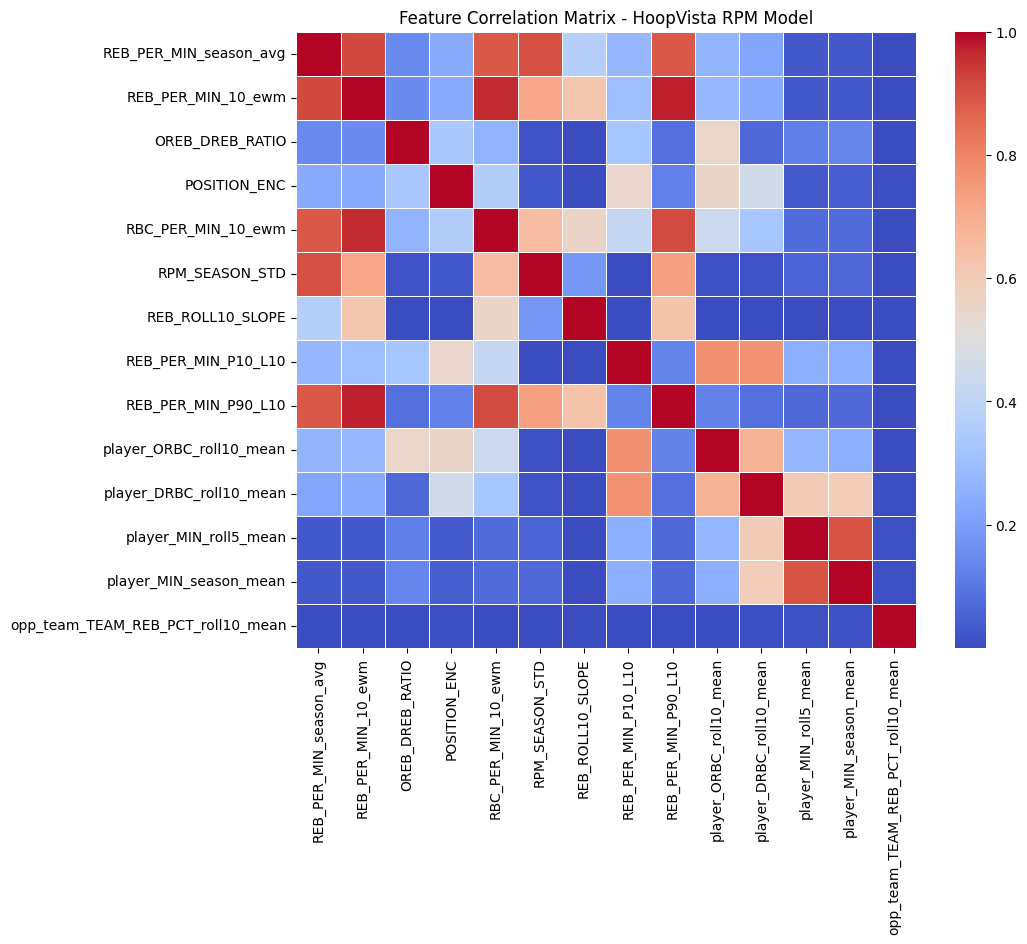

--- High Correlation Report (Threshold > 0.95) ---
REB_PER_MIN_P90_L10 <-> REB_PER_MIN_10_ewm: 0.9765
RBC_PER_MIN_10_ewm <-> REB_PER_MIN_10_ewm: 0.9621


['RBC_PER_MIN_10_ewm', 'REB_PER_MIN_P90_L10']

In [19]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the RPM model.
    """
    corr_matrix = df[features].corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista RPM Model')
    plt.show()

    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))

    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")

    return to_drop

correlated_features = analyze_correlations(df, FEATURE_COLS)
correlated_features


In [20]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S26
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S26 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S26 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S21–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).")

X_train_full = rpm_df[FEATURE_COLS]
y_train_full = rpm_df["REB_PER_MIN"]
X_ho         = rpm_holdout[FEATURE_COLS]
y_ho         = rpm_holdout["REB_PER_MIN"]
starting_ho  = rpm_holdout["STARTING"].values

# Early stopping on last 10% of training only — S26 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S26 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S21–S25)  : {wf_mae_mean:.4f}")
print(f"  Holdout MAE      (S26)            : {ho_mae:.4f}")
print(f"  Gap                               : {gap:+.4f}  {'⚠ investigate' if abs(gap) > 0.05 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred            = preds_ho[q_key]
    actual          = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta           = actual_coverage - target
    flag            = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.4f}  |  median: {np.median(interval_width):.4f}  |  std: {interval_width.std():.4f}")


── S26 Blind Holdout Evaluation ─────────────────────────────────────
  S21–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).

S26 Blind Holdout
  Overall  | n=24156 | MAE: 0.0734 | R²: 0.366 | 80% Coverage: 79.1%
  Starters   | n=13150 | MAE: 0.0670 | Coverage: 80.3%
  Bench      | n=11006 | MAE: 0.0810 | Coverage: 77.5%
  <0.15 reb/min        | n=11121 | MAE: 0.0621 | Coverage: 76.6%
  0.15-0.25 reb/min    | n= 7171 | MAE: 0.0523 | Coverage: 94.2%
  0.25-0.40 reb/min    | n= 4449 | MAE: 0.0957 | Coverage: 72.5%
  0.40+ reb/min        | n= 1415 | MAE: 0.1989 | Coverage: 41.8%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S21–S25)  : 0.0718
  Holdout MAE      (S26)            : 0.0734
  Gap                               : +0.0016  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 11.1%  target: 10%  delta: +1.1%  ✓
  q_0.50 | actual coverage: 51.8%  target: 50%  delt

In [21]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   FEATURE_COLS,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       rpm_df["GAME_DATE"].max(),
    "val_end":         rpm_holdout["GAME_DATE"].max(),
}

save_path = save_dir / f"rpm_quantile_xgb_{rpm_holdout['GAME_DATE'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.4f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_rpm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as FEATURE_COLS.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })


Saved to c:\Users\alexg\OneDrive\src\models\saved_models\rpm_quantile_xgb_2026-06-13.joblib
Loaded model MAE (S26 holdout): 0.0734
Trained on data up to        : 2025-06-22
Holdout through              : 2026-06-13
